Ritmo base definido pelo Vencedor (Carro 1): 82.6s
Sucesso! Gráfico salvo: RACE_TRACE_VENCEDOR.png


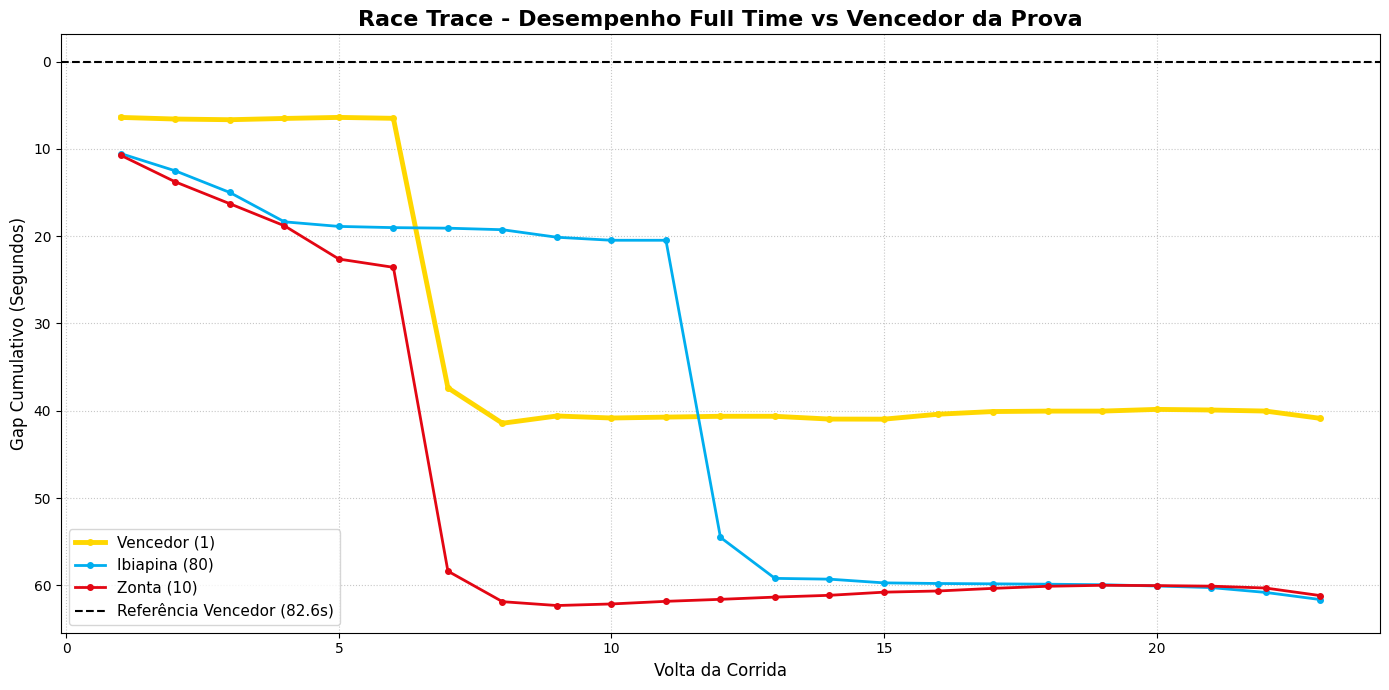

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

def gerar_race_trace_vencedor(csv_entrada, carros_equipe, carro_vencedor):
    
    df = pd.read_csv(csv_entrada, sep=';', decimal=',')
    
    # Garante que as colunas de carro sejam números inteiros para facilitar o filtro
    df['Carro'] = df['Carro'].astype(int)
    
    # 1. Calcula o ritmo real do vencedor (mediana das voltas limpas)
    df_vencedor = df[(df['Carro'] == carro_vencedor) & (df['Tipo_Volta'] == 'Push') & (~df['Outlier'])]
    
    if df_vencedor.empty:
        print(f"Erro: Não encontrei voltas limpas para o carro vencedor ({carro_vencedor}).")
        return
        
    tempo_referencia = round(df_vencedor['Lap Tm (Segundos)'].median(), 3)
    print(f"Ritmo base definido pelo Vencedor (Carro {carro_vencedor}): {tempo_referencia}s")
    
    plt.figure(figsize=(14, 7))
    
    # Dicionário de cores e nomes CORRIGIDO PARA O CARRO 80
    cores = {carro_vencedor: '#FFD700', 80: '#00AEEF', 10: '#E30613'} 
    nomes = {carro_vencedor: f'Vencedor ({carro_vencedor})', 80: 'Ibiapina (80)', 10: 'Zonta (10)'}
    
    # Junta o vencedor com os nossos pilotos para plotar
    carros_plotar = [carro_vencedor] + carros_equipe 
    
    for carro in carros_plotar:
        df_carro = df[df['Carro'] == carro].copy()
        df_carro = df_carro.sort_values(by='Lap')
        
        # Matemática do Trace Cumulativo
        df_carro['Delta_Ref'] = df_carro['Lap Tm (Segundos)'] - tempo_referencia
        df_carro['Race_Trace'] = df_carro['Delta_Ref'].cumsum()
        
        nome_piloto = nomes.get(carro, f'Carro {carro}')
        cor = cores.get(carro, 'black')
        
        # Deixa a linha do vencedor um pouco mais grossa para destacar
        espessura = 3.5 if carro == carro_vencedor else 2 
        
        plt.plot(df_carro['Lap'], df_carro['Race_Trace'], marker='o', markersize=4, 
                 linewidth=espessura, label=nome_piloto, color=cor)

    # A linha zero agora é o próprio ritmo ideal do vencedor
    plt.axhline(0, color='black', linestyle='--', linewidth=1.5, label=f'Referência Vencedor ({tempo_referencia}s)')
    
    plt.title('Race Trace - Desempenho Full Time vs Vencedor da Prova', fontsize=16, fontweight='bold')
    plt.xlabel('Volta da Corrida', fontsize=12)
    plt.ylabel('Gap Cumulativo (Segundos)', fontsize=12)
    plt.gca().invert_yaxis() # Inverte o Y (quem está em cima, está mais rápido)
    
    plt.legend(loc='best', fontsize=11)
    plt.grid(True, linestyle=':', alpha=0.7)
    plt.tight_layout()
    
    nome_arquivo = 'RACE_TRACE_VENCEDOR.png'
    plt.savefig(nome_arquivo, dpi=300)
    print(f"Sucesso! Gráfico salvo: {nome_arquivo}")
    plt.show()

# --- ÁREA DE EXECUÇÃO ---
gerar_race_trace_vencedor(
    csv_entrada='../data/03_processed/TELEMETRIA_ESTRATEGIA_P1.csv', 
    carros_equipe=[80, 10], 
    carro_vencedor=1  
)